# **Phase C — ML Modeling: Life Expectancy Prediction**

**Objective:** Train, tune, and evaluate machine learning models to predict Life Expectancy from country-level indicators. Produce SHAP-based feature importance to validate Phase B feature selection and feed back into Phase D clustering.

| Section | Description |
|---------|-------------|
| 1 | **Data loading & feature matrix construction** — lag-aware, Phase B–informed |
| 2 | **Train / validation / test split** — temporal hold-out + leave-one-out by continent |
| 3 | **Baseline models** — Linear Regression, Ridge, Lasso, ElasticNet |
| 4 | **Tree-based models** — Random Forest, Gradient Boosting, XGBoost, LightGBM |
| 5 | **Hyperparameter tuning** — RandomizedSearchCV + Optuna for top models |
| 6 | **Model comparison & selection** — CV R², RMSE, MAE across all models |
| 7 | **SHAP analysis** — global importance, dependence plots, force plots |
| 8 | **Residual analysis** — where the model is wrong and why |
| 9 | **Panel model baseline** — Fixed Effects as interpretability benchmark |
| 10 | **Export** — best model, SHAP values, feature ranking for Phase D |

**Prerequisites:** `phase_b_correlations.ipynb` → `candidates_correlations.json`, `lag_correlation_summary.csv`, `partial_correlations_gdp_control.csv`, `df_merged_all_imputed.csv`

## **~Libraries~**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json as _json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Sklearn — preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score, cross_validate, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge, RidgeCV, Lasso, ElasticNet, LinearRegression
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Sklearn — models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor

from scipy.stats import randint, uniform

# Gradient boosting
try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print('⚠️  XGBoost not installed — pip install xgboost')

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except ImportError:
    LGB_AVAILABLE = False
    print('⚠️  LightGBM not installed — pip install lightgbm')

# SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print('⚠️  SHAP not installed — pip install shap')

# Optuna (optional — for Bayesian tuning)
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print('ℹ️  Optuna not installed — using RandomizedSearchCV only')

# Joblib for model persistence
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

---
# **1. Data Loading & Feature Matrix Construction**

We load `candidates_correlations.json` from Phase B, apply lag recommendations from `lag_correlation_summary.csv`, drop GDP-confounded features flagged in `partial_correlations_gdp_control.csv`, then build the feature matrix from `df_merged_all_imputed.csv`.

In [2]:
TARGET  = 'Life Expectancy'
ID_COLS = ['Country', 'Continent', 'Year']
SEED    = 42

print('✅ Libraries loaded')
print(f'   XGBoost:  {XGB_AVAILABLE}  |  LightGBM: {LGB_AVAILABLE}  |  SHAP: {SHAP_AVAILABLE}  |  Optuna: {OPTUNA_AVAILABLE}')

✅ Libraries loaded
   XGBoost:  True  |  LightGBM: True  |  SHAP: True  |  Optuna: True


In [3]:
# ── 1a. Load Phase B outputs ──────────────────────────────────────────────────

df_raw = pd.read_csv('Phase_A_docs/df_merged_all_imputed.csv')
print(f'Raw panel: {df_raw.shape}  |  Countries: {df_raw["Country"].nunique()}  |  Years: {df_raw["Year"].min()}–{df_raw["Year"].max()}')

# Phase B candidates
with open('Phase_B_docs/candidates_correlations.json') as f:
    _raw_candidates = _json.load(f)

# Strip dataset__ prefix from values to get clean column names
candidates_correlations = {
    k: v.split('__')[-1] if '__' in v else v
    for k, v in _raw_candidates.items()
}
print(f'\nPhase B candidates: {len(candidates_correlations)}')
for k, v in candidates_correlations.items():
    print(f'  {k:<40} → {v}')

# ── 1b. Load lag recommendations from Phase B ─────────────────────────────────

try:
    df_lag_summary = pd.read_csv('Phase_B_docs/lag_correlation_summary.csv')
    # Build feature -> best_lag dict
    lag_map = {
        row['Feature']: int(row['Best lag'])
        for _, row in df_lag_summary.iterrows()
        if int(row['Best lag']) > 0  # only apply where lag > 0 adds value
    }
    print(f'Lag recommendations loaded: {len(lag_map)} features with lag > 0')
    for feat, lag in lag_map.items():
        print(f'  {feat:<40} lag = {lag}')
except FileNotFoundError:
    lag_map = {}
    print('ℹ️  lag_correlation_summary.csv not found — using lag=0 for all features')

# ── 1c. Load partial correlation results — flag GDP-confounded features ────────

try:
    df_partial = pd.read_csv('Phase_B_docs/partial_correlations_gdp_control.csv')
    gdp_confounded = df_partial[df_partial['GDP_Confounded'] == '⚠️']['Feature'].tolist()
    print(f'\nGDP-confounded features (from Phase B): {gdp_confounded}')
    print('  → These will be kept but flagged; remove from FORCE_EXCLUDE if you want to drop them.')
except FileNotFoundError:
    gdp_confounded = []
    print('ℹ️  partial_correlations_gdp_control.csv not found')

# ── 1d. Build feature matrix with optional lags ───────────────────────────────
#
# For each candidate feature:
#   - If feature has a lag recommendation: create feature_t-k (shift by k years within country)
#   - Otherwise: use contemporaneous value
# This ensures the model predicts LE(t) from feature(t-k) where k is Phase B's recommendation.

def build_feature_matrix(df_panel, candidates, lag_map, target=TARGET, id_cols=ID_COLS):
    """
    Build the feature matrix X and target y from the panel dataset.
    Applies within-country lags where specified.

    Returns
    -------
    df_model : pd.DataFrame  — full matrix with Country, Year, features, target
    feature_cols : list      — names of feature columns in df_model
    lag_applied  : dict      — {feature_col: lag used}
    """
    df = df_panel.sort_values(['Country', 'Year']).copy()
    feature_cols = []
    lag_applied  = {}

    for clean_name, col_name in candidates.items():
        # Resolve column — try exact match, then suffix match
        if col_name in df.columns:
            src_col = col_name
        else:
            matches = [c for c in df.columns if c.split('__')[-1] == col_name]
            if not matches:
                print(f'  ⚠️  Column "{col_name}" not found — skipping')
                continue
            src_col = matches[0]

        lag = lag_map.get(clean_name, 0)

        if lag > 0:
            feat_col = f'{clean_name}_lag{lag}'
            df[feat_col] = df.groupby('Country')[src_col].transform(lambda x: x.shift(lag))
            print(f'  ✅ {clean_name:<40} lag={lag}  →  {feat_col}')
        else:
            feat_col = clean_name
            if src_col != clean_name:
                df[feat_col] = df[src_col]
            print(f'  ✅ {clean_name:<40} lag=0')

        feature_cols.append(feat_col)
        lag_applied[feat_col] = lag

    # Keep only necessary columns
    keep_cols = [c for c in id_cols if c in df.columns] + [target] + feature_cols
    df_model  = df[keep_cols].dropna(subset=[target] + feature_cols)

    print(f'\n✅ Feature matrix built:')
    print(f'   Shape         : {df_model.shape}')
    print(f'   Countries     : {df_model["Country"].nunique()}')
    print(f'   Years         : {df_model["Year"].min()}–{df_model["Year"].max()}')
    print(f'   Features used : {len(feature_cols)}')

    return df_model, feature_cols, lag_applied


print('Building feature matrix...')
df_model, feature_cols, lag_applied = build_feature_matrix(df_raw, candidates_correlations, lag_map)

print(f'\nFeatures: {feature_cols}')

# ── 1e. Feature matrix overview ───────────────────────────────────────────────

print(f'Target distribution:')
print(f'  Mean: {df_model[TARGET].mean():.1f}  |  Std: {df_model[TARGET].std():.1f}')
print(f'  Min: {df_model[TARGET].min():.1f}    |  Max: {df_model[TARGET].max():.1f}')

print(f'\nFeature summary:')
display(df_model[feature_cols].describe().round(2))

# Missing values in feature matrix (should be near 0 after imputation + lag)
miss = df_model[feature_cols].isnull().sum()
if miss.sum() > 0:
    print(f'\n⚠️  Remaining NaN after lag construction:')
    print(miss[miss > 0].to_string())
else:
    print(f'\n✅ No missing values in feature matrix')

Raw panel: (3096, 67)  |  Countries: 129  |  Years: 2000–2023

Phase B candidates: 12
  Child mortality rate                     → Child mortality rate
  Tuberculosis                             → Tuberculosis
  Maternal disorders                       → Maternal disorders
  Median income or consumption per day     → Median income or consumption per day
  Alzheimer's disease and other dementias  → Alzheimer's disease and other dementias
  Parkinson's disease                      → Parkinson's disease
  Share below $3.65 a day                  → Share below $3.65 a day
  Share below $2.15 a day                  → Share below $2.15 a day
  GDP per Capita                           → GDP per Capita
  Lower respiratory infections             → Lower respiratory infections
  Homicide Rate                            → Homicide Rate
  HIV/AIDS                                 → HIV/AIDS
Lag recommendations loaded: 5 features with lag > 0
  HepB3                                    lag = 1
  Pol3

,Child mortality rate,Tuberculosis,Maternal disorders,Median income or consumption per day,Alzheimer's disease and other dementias,Parkinson's disease,Share below $3.65 a day,Share below $2.15 a day,GDP per Capita_lag1,Lower respiratory infections,Homicide Rate,HIV/AIDS
count,2967.00,2967.00,2967.00,2967.00,2967.00,2967.00,2967.00,2967.00,2967.00,2967.00,2967.00,2967.00
mean,3.04,15.06,3.10,16.78,22.22,5.10,22.38,11.60,17443.19,38.13,7.17,41.18
std,3.52,23.76,5.14,17.20,18.98,3.69,27.98,19.11,18516.60,27.87,11.33,121.89
min,0.21,0.15,0.00,1.15,0.81,0.44,0.00,0.00,255.83,5.16,0.00,0.00
25%,0.62,1.14,0.10,4.39,7.15,1.97,0.78,0.24,4307.34,18.06,1.35,0.42
50%,1.69,3.97,0.75,9.61,16.24,3.80,7.83,1.41,10897.64,28.28,2.97,2.10
75%,4.01,18.89,3.72,22.74,33.74,8.04,39.84,14.57,24527.78,52.08,7.12,11.22
max,21.82,157.13,42.30,77.76,167.72,17.50,94.59,81.50,134965.82,228.14,106.82,995.15



✅ No missing values in feature matrix


---
# **2. Train / Validation / Test Split**

Panel data requires careful splitting to avoid leakage. We use:
- **Temporal hold-out**: years 2019–2023 → test set (never seen during training or tuning)
- **Cross-validation**: 5-fold KFold on the training set (2000–2018) for model selection
- **Continent robustness check**: evaluate on each continent separately to detect bias

We do NOT split by country randomly — that would leak temporal trends.

In [4]:
# ── 2a. Temporal train/test split ─────────────────────────────────────────────

TEST_YEARS  = range(2019, 2024)  # hold-out: last 5 years
TRAIN_YEARS = range(2000, 2019)  # training: 2000–2018

df_train = df_model[df_model['Year'].isin(TRAIN_YEARS)].copy()
df_test  = df_model[df_model['Year'].isin(TEST_YEARS)].copy()

X_train = df_train[feature_cols].values
y_train = df_train[TARGET].values
X_test  = df_test[feature_cols].values
y_test  = df_test[TARGET].values

print(f'Train set: {df_train.shape}  |  years {df_train["Year"].min()}–{df_train["Year"].max()}')
print(f'Test set:  {df_test.shape}   |  years {df_test["Year"].min()}–{df_test["Year"].max()}')
print(f'\nTrain LE: mean={y_train.mean():.1f}  std={y_train.std():.1f}')
print(f'Test  LE: mean={y_test.mean():.1f}   std={y_test.std():.1f}')

# ── 2b. Scale features ────────────────────────────────────────────────────────
# RobustScaler — median/IQR-based, less sensitive to outlier countries

scaler  = RobustScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('✅ Features scaled with RobustScaler (fit on train only)')

# CV strategy for model selection
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

# Helper: evaluate a fitted model on test set
def evaluate_on_test(model, X_test_s, y_test, label=''):
    y_pred = model.predict(X_test_s)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    print(f'{label:<35}  R²={r2:.3f}  RMSE={rmse:.2f}  MAE={mae:.2f}')
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'y_pred': y_pred}

Train set: (2322, 16)  |  years 2001–2018
Test set:  (645, 16)   |  years 2019–2023

Train LE: mean=71.0  std=8.7
Test  LE: mean=73.5   std=6.8
✅ Features scaled with RobustScaler (fit on train only)


In [5]:
# ── Full 12-feature OLS (diagnostic only) ─────────────────────────────────────
# This runs the full model including collinear variables (Share below $2.15,
# Parkinson's, Maternal disorders, Share below $3.65).
# Wrong signs on some coefficients are expected — see cell 9 for the clean
# reduced model used for Phase D policy interpretation.
#
# Kept here for reference only. Skip to cell 9 for the policy model.

# ── OLS ───────────────────────────────────────────────────────────────────────
X_sm = sm.add_constant(X_train_s)
ols_sm = sm.OLS(y_train, X_sm).fit()
print('\nstatsmodels OLS summary (for coefficient inference):')
print(ols_sm.summary())

# OLS test R²
y_pred_ols = ols_sm.predict(sm.add_constant(X_test_s))
print(f'\nOLS Test R²:  {r2_score(y_test, y_pred_ols):.3f}')
print(f'OLS Train R²: {ols_sm.rsquared:.3f}')

# ── Ridge CV ──────────────────────────────────────────────────────────────────
ridge_cv = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0], cv=cv, scoring='r2')
ridge_cv.fit(X_train_s, y_train)

print(f'\nRidge best alpha: {ridge_cv.alpha_}')
print(f'Ridge Train R²:   {ridge_cv.score(X_train_s, y_train):.3f}')
print(f'Ridge Test R²:    {r2_score(y_test, ridge_cv.predict(X_test_s)):.3f}')

# ── Coefficients ──────────────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature':    feature_cols,
    'OLS_Coef':   ols_sm.params[1:],
    'Ridge_Coef': ridge_cv.coef_,
    'OLS_pvalue': ols_sm.pvalues[1:]
}).sort_values('OLS_Coef', key=abs, ascending=False)
print('\nCoefficients (RobustScaler-standardised):')
print(coef_df.to_string(index=False))


statsmodels OLS summary (for coefficient inference):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.942
Method:                 Least Squares   F-statistic:                     3114.
Date:                Sun, 22 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:52:25   Log-Likelihood:                -5019.9
No. Observations:                2322   AIC:                         1.007e+04
Df Residuals:                    2309   BIC:                         1.014e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

In [6]:
# ── 2c. Reduced OLS — drop collinear/wrong-sign features ─────────────────────
# These three features showed wrong signs in full OLS due to multicollinearity.
# This reduced model is used for Phase D policy coefficient interpretation.

drop_vars = ['Share below $2.15 a day', 'Share below $3.65 a day', "Parkinson's disease", 'Maternal disorders']
feature_cols_reduced = [f for f in feature_cols if f not in drop_vars]
idx_r = [feature_cols.index(f) for f in feature_cols_reduced]

X_train_r = X_train_s[:, idx_r]
X_test_r  = X_test_s[:,  idx_r]

X_sm_r = sm.add_constant(X_train_r)
ols_reduced = sm.OLS(y_train, X_sm_r).fit()
print(ols_reduced.summary())

y_pred_r = ols_reduced.predict(sm.add_constant(X_test_r))
print(f'\nReduced OLS Test R²: {r2_score(y_test, y_pred_r):.3f}')
print(f'Reduced OLS Train R²: {ols_reduced.rsquared:.3f}')

# Store coefficients for Phase D advisory use
ci = ols_reduced.conf_int()

coef_policy = pd.DataFrame({
    'Feature':     feature_cols_reduced,
    'Coefficient': list(ols_reduced.params[1:]),
    'Std_Error':   list(ols_reduced.bse[1:]),
    'p_value':     list(ols_reduced.pvalues[1:]),
    'CI_lower':    list(ci[1:, 0]),
    'CI_upper':    list(ci[1:, 1]),
}).sort_values('Coefficient', key=abs, ascending=False)

print('\nPolicy coefficients:')
print(coef_policy.to_string(index=False))

coef_policy.to_csv('Phase_C_docs/policy_coefficients.csv', index=False)
print('\n✅ Saved: policy_coefficients.csv')

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.941
Model:                            OLS   Adj. R-squared:                  0.940
Method:                 Least Squares   F-statistic:                     4572.
Date:                Sun, 22 Feb 2026   Prob (F-statistic):               0.00
Time:                        16:52:25   Log-Likelihood:                -5045.1
No. Observations:                2322   AIC:                         1.011e+04
Df Residuals:                    2313   BIC:                         1.016e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         72.8662      0.067   1087.128      0.0

---
# **3. Baseline Models — Linear Family**

Establishing baselines before tree-based models ensures we understand what a simple linear model can already explain. A gradient boosting model that barely beats Ridge regression is not necessarily worth the interpretability cost.

Dummy (mean)                         R²=-0.138  RMSE=7.30  MAE=6.14

OLS CV R²: 0.941 ± 0.004
OLS                                  R²=0.880  RMSE=2.37  MAE=1.86
Ridge CV R²: 0.941 ± 0.004
Ridge                                R²=0.880  RMSE=2.37  MAE=1.86
Lasso CV R²: 0.940 ± 0.004
Lasso                                R²=0.882  RMSE=2.35  MAE=1.82
ElasticNet CV R²: 0.938 ± 0.004
ElasticNet                           R²=0.876  RMSE=2.41  MAE=1.88


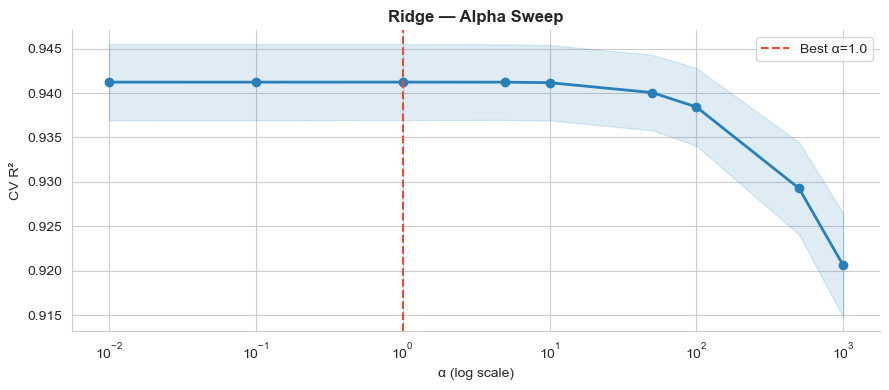

Best Ridge alpha: 1.0
Ridge (tuned)                        R²=0.880  RMSE=2.37  MAE=1.86


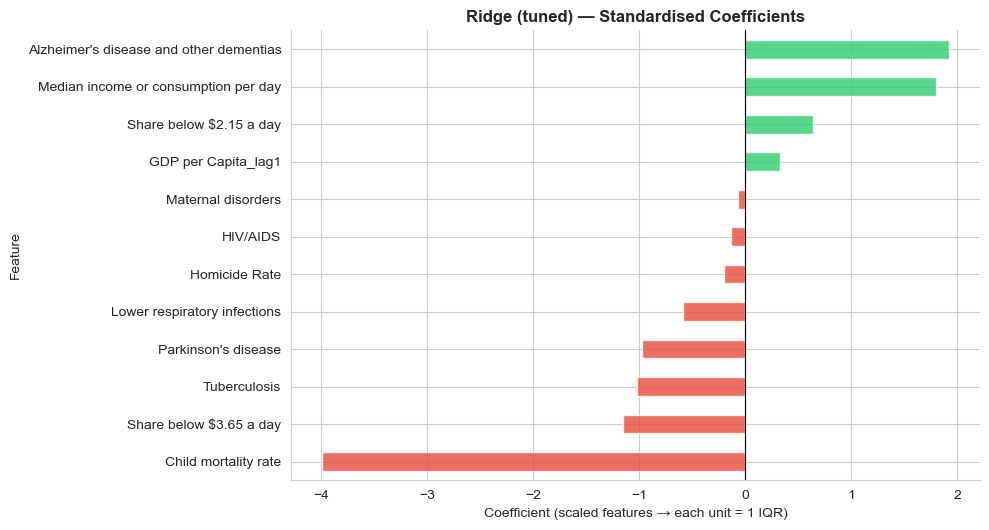

Features zeroed by Lasso (3): ["Parkinson's disease", 'Share below $3.65 a day', 'Share below $2.15 a day']

Full coefficient table:


,OLS,Ridge,Lasso,ElasticNet
Feature,,,,
Child mortality rate,-4.005,-3.989,-4.063,-2.891
Tuberculosis,-1.015,-1.017,-0.978,-1.088
Maternal disorders,-0.063,-0.070,-0.199,-0.566
Median income or consumption per day,1.808,1.800,1.900,1.479
Alzheimer's disease and other dementias,1.938,1.921,1.000,1.213
Parkinson's disease,-1.001,-0.973,0.000,0.064
Share below $3.65 a day,-1.171,-1.153,-0.000,-0.189
Share below $2.15 a day,0.648,0.639,-0.000,-0.000
GDP per Capita_lag1,0.319,0.329,0.269,0.728


In [7]:
# ── 3a. Dummy baseline + linear models ───────────────────────────────────────

results_all = {}   # collects all model results for Section 6 comparison

# -- Dummy (predict mean) --
dummy = DummyRegressor(strategy='mean')
dummy.fit(X_train_s, y_train)
results_all['Dummy (mean)'] = evaluate_on_test(dummy, X_test_s, y_test, 'Dummy (mean)')

# -- OLS --
ols = LinearRegression()
ols.fit(X_train_s, y_train)
ols_cv = cross_val_score(ols, X_train_s, y_train, cv=cv, scoring='r2')
print(f'\nOLS CV R²: {ols_cv.mean():.3f} ± {ols_cv.std():.3f}')
results_all['OLS'] = evaluate_on_test(ols, X_test_s, y_test, 'OLS')
results_all['OLS']['CV_R2']  = ols_cv.mean()
results_all['OLS']['CV_Std'] = ols_cv.std()

# -- Ridge --
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_s, y_train)
ridge_cv = cross_val_score(ridge, X_train_s, y_train, cv=cv, scoring='r2')
print(f'Ridge CV R²: {ridge_cv.mean():.3f} ± {ridge_cv.std():.3f}')
results_all['Ridge'] = evaluate_on_test(ridge, X_test_s, y_test, 'Ridge')
results_all['Ridge']['CV_R2']  = ridge_cv.mean()
results_all['Ridge']['CV_Std'] = ridge_cv.std()

# -- Lasso --
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_s, y_train)
lasso_cv = cross_val_score(lasso, X_train_s, y_train, cv=cv, scoring='r2')
print(f'Lasso CV R²: {lasso_cv.mean():.3f} ± {lasso_cv.std():.3f}')
results_all['Lasso'] = evaluate_on_test(lasso, X_test_s, y_test, 'Lasso')
results_all['Lasso']['CV_R2']  = lasso_cv.mean()
results_all['Lasso']['CV_Std'] = lasso_cv.std()

# -- ElasticNet --
enet = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
enet.fit(X_train_s, y_train)
enet_cv = cross_val_score(enet, X_train_s, y_train, cv=cv, scoring='r2')
print(f'ElasticNet CV R²: {enet_cv.mean():.3f} ± {enet_cv.std():.3f}')
results_all['ElasticNet'] = evaluate_on_test(enet, X_test_s, y_test, 'ElasticNet')
results_all['ElasticNet']['CV_R2']  = enet_cv.mean()
results_all['ElasticNet']['CV_Std'] = enet_cv.std()

# ── 3b. Ridge alpha sweep ─────────────────────────────────────────────────────

alphas = [0.01, 0.1, 1, 5, 10, 50, 100, 500, 1000]
ridge_scores = []

for a in alphas:
    r = Ridge(alpha=a)
    sc = cross_val_score(r, X_train_s, y_train, cv=cv, scoring='r2')
    ridge_scores.append({'alpha': a, 'CV_R2': sc.mean(), 'CV_Std': sc.std()})

df_ridge_sweep = pd.DataFrame(ridge_scores)
best_alpha = df_ridge_sweep.loc[df_ridge_sweep['CV_R2'].idxmax(), 'alpha']

fig, ax = plt.subplots(figsize=(9, 4))
ax.semilogx(df_ridge_sweep['alpha'], df_ridge_sweep['CV_R2'], 'o-', color='#2980b9', linewidth=2)
ax.fill_between(df_ridge_sweep['alpha'],
                df_ridge_sweep['CV_R2'] - df_ridge_sweep['CV_Std'],
                df_ridge_sweep['CV_R2'] + df_ridge_sweep['CV_Std'],
                alpha=0.15, color='#2980b9')
ax.axvline(best_alpha, color='#e74c3c', linestyle='--', label=f'Best α={best_alpha}')
ax.set_xlabel('α (log scale)')
ax.set_ylabel('CV R²')
ax.set_title('Ridge — Alpha Sweep', fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f'Best Ridge alpha: {best_alpha}')

# Refit best Ridge
ridge_best = Ridge(alpha=best_alpha)
ridge_best.fit(X_train_s, y_train)
results_all['Ridge (tuned)'] = evaluate_on_test(ridge_best, X_test_s, y_test, 'Ridge (tuned)')
results_all['Ridge (tuned)']['CV_R2']  = df_ridge_sweep['CV_R2'].max()
results_all['Ridge (tuned)']['CV_Std'] = df_ridge_sweep.loc[df_ridge_sweep['CV_R2'].idxmax(), 'CV_Std']

# ── 3c. Linear model coefficients ─────────────────────────────────────────────

coef_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'OLS'       : ols.coef_,
    'Ridge'     : ridge_best.coef_,
    'Lasso'     : lasso.coef_,
    'ElasticNet': enet.coef_,
}).set_index('Feature')

fig, ax = plt.subplots(figsize=(10, max(5, len(feature_cols) * 0.45)))
coef_df['Ridge'].sort_values().plot.barh(ax=ax, color=[
    '#e74c3c' if v < 0 else '#2ecc71' for v in coef_df['Ridge'].sort_values()
], alpha=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Ridge (tuned) — Standardised Coefficients', fontweight='bold')
ax.set_xlabel('Coefficient (scaled features → each unit = 1 IQR)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

# Lasso zero-out report
zeroed = coef_df[coef_df['Lasso'] == 0].index.tolist()
print(f'Features zeroed by Lasso ({len(zeroed)}): {zeroed}')
print('\nFull coefficient table:')
display(coef_df.round(3))

---
# **4. Tree-Based Models**

In [8]:
# ── 4a. Random Forest ─────────────────────────────────────────────────────────

rf = RandomForestRegressor(
    n_estimators=500, max_depth=None,
    min_samples_leaf=3, max_features='sqrt',
    random_state=SEED, n_jobs=-1
)
rf.fit(X_train_s, y_train)
rf_cv = cross_val_score(rf, X_train_s, y_train, cv=cv, scoring='r2', n_jobs=-1)
print(f'RF CV R²: {rf_cv.mean():.3f} ± {rf_cv.std():.3f}')
results_all['Random Forest'] = evaluate_on_test(rf, X_test_s, y_test, 'Random Forest')
results_all['Random Forest']['CV_R2']  = rf_cv.mean()
results_all['Random Forest']['CV_Std'] = rf_cv.std()

# ── 4b. Gradient Boosting (sklearn) ───────────────────────────────────────────

gbm = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05,
    max_depth=4, subsample=0.8,
    min_samples_leaf=5, random_state=SEED
)
gbm.fit(X_train_s, y_train)
gbm_cv = cross_val_score(gbm, X_train_s, y_train, cv=cv, scoring='r2')
print(f'GBM CV R²: {gbm_cv.mean():.3f} ± {gbm_cv.std():.3f}')
results_all['Gradient Boosting'] = evaluate_on_test(gbm, X_test_s, y_test, 'Gradient Boosting')
results_all['Gradient Boosting']['CV_R2']  = gbm_cv.mean()
results_all['Gradient Boosting']['CV_Std'] = gbm_cv.std()

# ── 4c. XGBoost ───────────────────────────────────────────────────────────────

if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(
        n_estimators=400, learning_rate=0.05,
        max_depth=4, subsample=0.8,
        colsample_bytree=0.8, reg_alpha=0.1,
        reg_lambda=1.0, random_state=SEED,
        verbosity=0, n_jobs=-1
    )
    xgb_model.fit(X_train_s, y_train)
    xgb_cv = cross_val_score(xgb_model, X_train_s, y_train, cv=cv, scoring='r2', n_jobs=-1)
    print(f'XGBoost CV R²: {xgb_cv.mean():.3f} ± {xgb_cv.std():.3f}')
    results_all['XGBoost'] = evaluate_on_test(xgb_model, X_test_s, y_test, 'XGBoost')
    results_all['XGBoost']['CV_R2']  = xgb_cv.mean()
    results_all['XGBoost']['CV_Std'] = xgb_cv.std()
else:
    print('XGBoost not available — skipping')

# ── 4d. LightGBM ──────────────────────────────────────────────────────────────

if LGB_AVAILABLE:
    lgb_model = lgb.LGBMRegressor(
        n_estimators=400, learning_rate=0.05,
        max_depth=5, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=SEED, n_jobs=-1,
        verbose=-1
    )
    lgb_model.fit(X_train_s, y_train)
    lgb_cv = cross_val_score(lgb_model, X_train_s, y_train, cv=cv, scoring='r2', n_jobs=-1)
    print(f'LightGBM CV R²: {lgb_cv.mean():.3f} ± {lgb_cv.std():.3f}')
    results_all['LightGBM'] = evaluate_on_test(lgb_model, X_test_s, y_test, 'LightGBM')
    results_all['LightGBM']['CV_R2']  = lgb_cv.mean()
    results_all['LightGBM']['CV_Std'] = lgb_cv.std()
else:
    print('LightGBM not available — skipping')

RF CV R²: 0.988 ± 0.002
Random Forest                        R²=0.921  RMSE=1.92  MAE=1.46
GBM CV R²: 0.989 ± 0.001
Gradient Boosting                    R²=0.916  RMSE=1.99  MAE=1.51
XGBoost CV R²: 0.990 ± 0.002
XGBoost                              R²=0.917  RMSE=1.97  MAE=1.49
LightGBM CV R²: 0.991 ± 0.001
LightGBM                             R²=0.923  RMSE=1.90  MAE=1.42


---
# **5. Hyperparameter Tuning — Top Models**

We tune Random Forest and the best gradient boosting model from Section 4. If Optuna is available, we use Bayesian optimization; otherwise we fall back to RandomizedSearchCV.

In [9]:
# ── 5a. Random Forest tuning — RandomizedSearchCV ─────────────────────────────
rf_param_dist = {
    'n_estimators'    : randint(200, 800),
    'max_depth'       : [None, 5, 10, 15, 20],
    'min_samples_leaf': randint(1, 10),
    'max_features'    : ['sqrt', 'log2', 0.5, 0.7],
    'max_samples'     : uniform(0.6, 0.4),
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    rf_param_dist, n_iter=40, cv=cv,
    scoring='r2', random_state=SEED,
    verbose=0, refit=True, n_jobs=-1
)
rf_search.fit(X_train_s, y_train)

print(f'RF best CV R²: {rf_search.best_score_:.3f}')
print(f'RF best params: {rf_search.best_params_}')

rf_tuned = rf_search.best_estimator_
results_all['RF (tuned)'] = evaluate_on_test(rf_tuned, X_test_s, y_test, 'RF (tuned)')
results_all['RF (tuned)']['CV_R2']  = rf_search.best_score_
results_all['RF (tuned)']['CV_Std'] = rf_search.cv_results_['std_test_score'][rf_search.best_index_]

# ── 5b. Gradient Boosting tuning ──────────────────────────────────────────────
# Tune whichever boosting model is available (XGBoost preferred, else sklearn GBM)

if OPTUNA_AVAILABLE and XGB_AVAILABLE:
    # Optuna Bayesian tuning for XGBoost
    def xgb_objective(trial):
        params = {
            'n_estimators'     : trial.suggest_int('n_estimators', 100, 800),
            'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth'        : trial.suggest_int('max_depth', 3, 8),
            'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'random_state'     : SEED, 'verbosity': 0, 'n_jobs': -1
        }
        model = xgb.XGBRegressor(**params)
        scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='r2', n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

    print(f'\nXGBoost Optuna best CV R²: {study.best_value:.3f}')
    print(f'Best params: {study.best_params}')

    boost_tuned = xgb.XGBRegressor(**study.best_params, random_state=SEED, verbosity=0)
    boost_tuned.fit(X_train_s, y_train)
    results_all['XGBoost (Optuna)'] = evaluate_on_test(boost_tuned, X_test_s, y_test, 'XGBoost (Optuna)')
    results_all['XGBoost (Optuna)']['CV_R2']  = study.best_value
    results_all['XGBoost (Optuna)']['CV_Std'] = 0.0

elif XGB_AVAILABLE:
    # RandomizedSearchCV for XGBoost
    xgb_param_dist = {
        'n_estimators'    : randint(100, 600),
        'learning_rate'   : uniform(0.01, 0.29),
        'max_depth'       : randint(3, 9),
        'subsample'       : uniform(0.5, 0.5),
        'colsample_bytree': uniform(0.5, 0.5),
        'reg_alpha'       : uniform(0, 5),
        'reg_lambda'      : uniform(0.5, 5),
    }
    xgb_search = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=SEED, verbosity=0, n_jobs=-1),
        xgb_param_dist, n_iter=40, cv=cv,
        scoring='r2', random_state=SEED, n_jobs=-1
    )
    xgb_search.fit(X_train_s, y_train)
    boost_tuned = xgb_search.best_estimator_
    print(f'XGBoost RandomSearch best CV R²: {xgb_search.best_score_:.3f}')
    results_all['XGBoost (tuned)'] = evaluate_on_test(boost_tuned, X_test_s, y_test, 'XGBoost (tuned)')
    results_all['XGBoost (tuned)']['CV_R2']  = xgb_search.best_score_
    results_all['XGBoost (tuned)']['CV_Std'] = xgb_search.cv_results_['std_test_score'][xgb_search.best_index_]

else:
    # Fall back to GBM tuning
    gbm_param_dist = {
        'n_estimators'    : randint(100, 600),
        'learning_rate'   : uniform(0.01, 0.29),
        'max_depth'       : randint(2, 7),
        'subsample'       : uniform(0.5, 0.5),
        'min_samples_leaf': randint(3, 15),
    }
    gbm_search = RandomizedSearchCV(
        GradientBoostingRegressor(random_state=SEED),
        gbm_param_dist, n_iter=40, cv=cv,
        scoring='r2', random_state=SEED
    )
    gbm_search.fit(X_train_s, y_train)
    boost_tuned = gbm_search.best_estimator_
    print(f'GBM RandomSearch best CV R²: {gbm_search.best_score_:.3f}')
    results_all['GBM (tuned)'] = evaluate_on_test(boost_tuned, X_test_s, y_test, 'GBM (tuned)')
    results_all['GBM (tuned)']['CV_R2']  = gbm_search.best_score_
    results_all['GBM (tuned)']['CV_Std'] = gbm_search.cv_results_['std_test_score'][gbm_search.best_index_]

RF best CV R²: 0.992
RF best params: {'max_depth': 15, 'max_features': 0.5, 'max_samples': np.float64(0.9046478461314871), 'min_samples_leaf': 1, 'n_estimators': 493}
RF (tuned)                           R²=0.923  RMSE=1.89  MAE=1.41


  0%|          | 0/50 [00:00<?, ?it/s]


XGBoost Optuna best CV R²: 0.995
Best params: {'n_estimators': 686, 'learning_rate': 0.024601634064283076, 'max_depth': 8, 'subsample': 0.5310701951388933, 'colsample_bytree': 0.901620432359221, 'reg_alpha': 0.06460400076760447, 'reg_lambda': 0.16225141201465465}
XGBoost (Optuna)                     R²=0.929  RMSE=1.82  MAE=1.33


---
# **6. Model Comparison & Selection**

Model Comparison:


,Rank,Model,CV R²,CV Std,Test R²,Test RMSE,Test MAE
0,1,XGBoost (Optuna),0.995,0.000,0.929,1.82,1.33
1,2,LightGBM,0.991,0.001,0.923,1.90,1.42
2,3,RF (tuned),0.992,0.001,0.923,1.89,1.41
3,4,Random Forest,0.988,0.002,0.921,1.92,1.46
4,5,XGBoost,0.990,0.002,0.917,1.97,1.49
5,6,Gradient Boosting,0.989,0.001,0.916,1.99,1.51
6,7,Lasso,0.940,0.004,0.882,2.35,1.82
7,8,OLS,0.941,0.004,0.880,2.37,1.86
8,9,Ridge,0.941,0.004,0.880,2.37,1.86
9,10,Ridge (tuned),0.941,0.004,0.880,2.37,1.86



🏆 Best model: XGBoost (Optuna)  (Test R²=0.929)


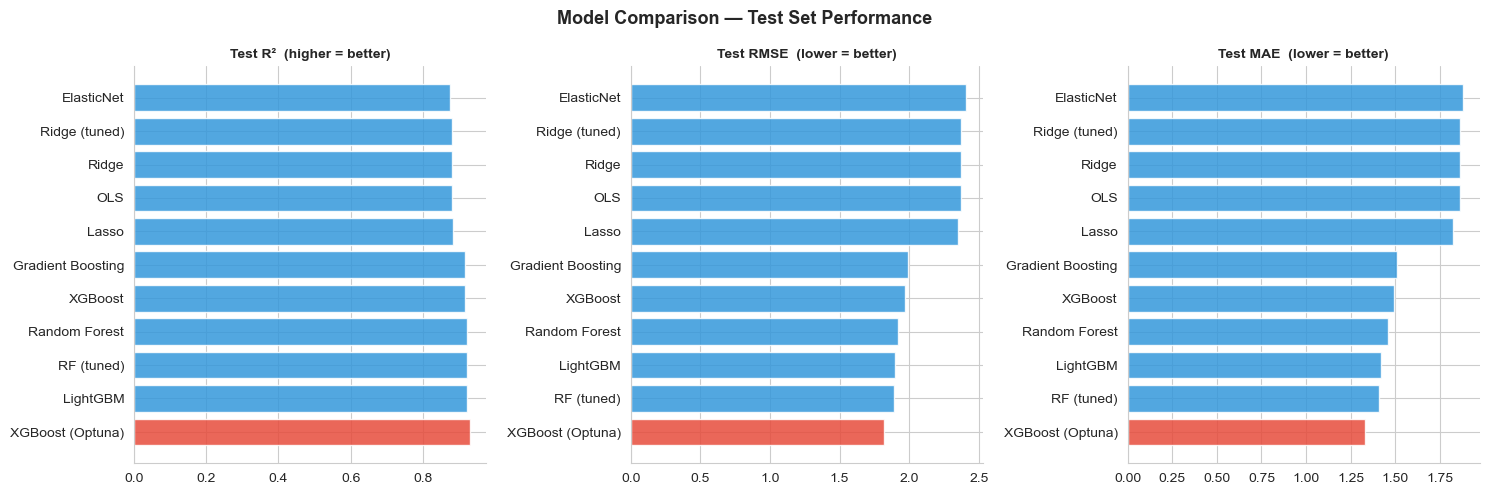

✅ Final model: XGBoost (Optuna)
   Test R²=0.929  RMSE=1.82  MAE=1.33


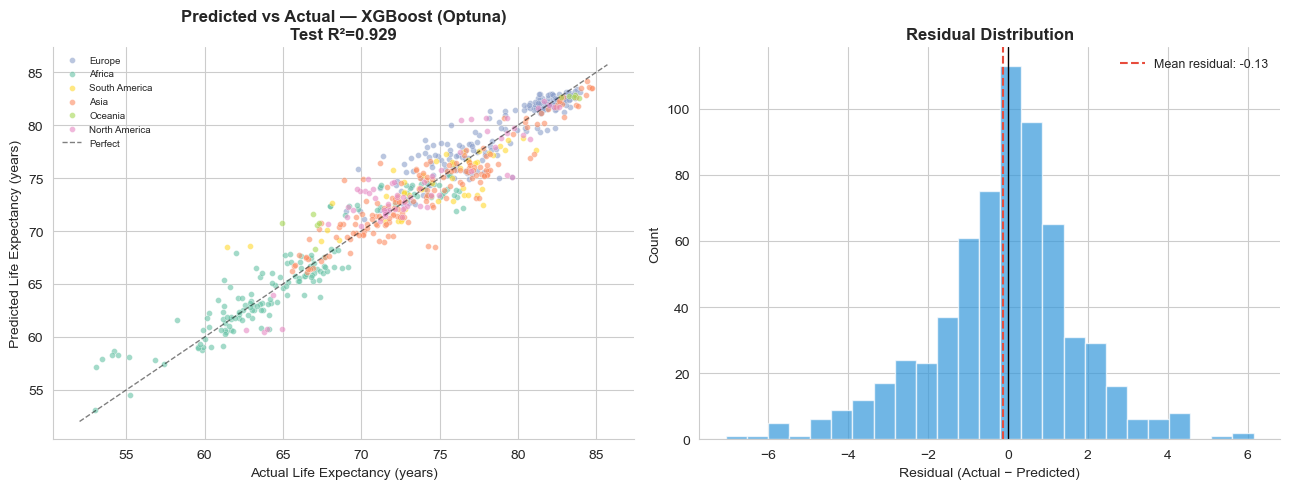

Performance by Continent (test set):


,Continent,N,R²,RMSE,MAE
0,Africa,160,0.892,1.80,1.34
1,Asia,165,0.871,1.76,1.31
2,Europe,195,0.826,1.56,1.12
3,North America,65,0.808,2.07,1.56
4,Oceania,10,0.882,2.90,2.23
5,South America,50,0.657,2.34,1.73



⚠️  Model underperforms on: ['South America']
   Consider: continent-specific models, or adding continent as a feature


In [10]:
# ── 6a. Comparison table ──────────────────────────────────────────────────────

rows = []
for name, res in results_all.items():
    rows.append({
        'Model'   : name,
        'CV R²'   : round(res.get('CV_R2', np.nan), 3),
        'CV Std'  : round(res.get('CV_Std', np.nan), 3),
        'Test R²' : round(res['R2'], 3),
        'Test RMSE': round(res['RMSE'], 2),
        'Test MAE' : round(res['MAE'], 2),
    })

df_comparison = pd.DataFrame(rows).sort_values('Test R²', ascending=False).reset_index(drop=True)
df_comparison['Rank'] = df_comparison.index + 1

print('Model Comparison:')
display(df_comparison[['Rank', 'Model', 'CV R²', 'CV Std', 'Test R²', 'Test RMSE', 'Test MAE']])

best_model_name = df_comparison.iloc[0]['Model']
print(f'\n🏆 Best model: {best_model_name}  (Test R²={df_comparison.iloc[0]["Test R²"]:.3f})')

# ── 6b. Comparison chart ──────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df_plot = df_comparison[df_comparison['Model'] != 'Dummy (mean)'].copy()
colors  = ['#e74c3c' if i == 0 else '#3498db' for i in range(len(df_plot))]

for ax, metric, title in zip(axes,
                              ['Test R²', 'Test RMSE', 'Test MAE'],
                              ['Test R²  (higher = better)',
                               'Test RMSE  (lower = better)',
                               'Test MAE  (lower = better)']):
    ascending = metric != 'Test R²'
    df_sorted = df_plot.sort_values(metric, ascending=ascending)
    ax.barh(df_sorted['Model'], df_sorted[metric],
            color=['#e74c3c' if m == best_model_name else '#3498db'
                   for m in df_sorted['Model']], alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Model Comparison — Test Set Performance', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 6c. Select final model ────────────────────────────────────────────────────
# Map best model name to the fitted object

model_registry = {
    'Dummy (mean)'      : dummy,
    'OLS'               : ols,
    'Ridge'             : ridge,
    'Ridge (tuned)'     : ridge_best,
    'Lasso'             : lasso,
    'ElasticNet'        : enet,
    'Random Forest'     : rf,
    'RF (tuned)'        : rf_tuned,
    'Gradient Boosting' : gbm,
}
if XGB_AVAILABLE:
    model_registry['XGBoost'] = xgb_model
if LGB_AVAILABLE:
    model_registry['LightGBM'] = lgb_model
if 'boost_tuned' in dir():
    for k in ['XGBoost (Optuna)', 'XGBoost (tuned)', 'GBM (tuned)']:
        if k in results_all:
            model_registry[k] = boost_tuned

best_model = model_registry[best_model_name]
y_pred_test = best_model.predict(X_test_s)

print(f'✅ Final model: {best_model_name}')
print(f'   Test R²={results_all[best_model_name]["R2"]:.3f}  '
      f'RMSE={results_all[best_model_name]["RMSE"]:.2f}  '
      f'MAE={results_all[best_model_name]["MAE"]:.2f}')

# ── 6d. Predicted vs actual + continent breakdown ─────────────────────────────

df_test_results = df_test.copy()
df_test_results['Predicted'] = y_pred_test
df_test_results['Residual']  = df_test_results[TARGET] - df_test_results['Predicted']

# Predicted vs actual scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A — overall
ax = axes[0]
cont_colors = {
    'Africa': '#66c2a5', 'Asia': '#fc8d62', 'Europe': '#8da0cb',
    'North America': '#e78ac3', 'Oceania': '#a6d854', 'South America': '#ffd92f'
}
for cont in df_test_results['Continent'].dropna().unique():
    sub = df_test_results[df_test_results['Continent'] == cont]
    ax.scatter(sub[TARGET], sub['Predicted'],
               color=cont_colors.get(cont, 'grey'), alpha=0.6, s=18,
               edgecolor='white', linewidth=0.3, label=cont)
lo, hi = df_test_results[TARGET].min() - 1, df_test_results[TARGET].max() + 1
ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.5, label='Perfect')
ax.set_xlabel('Actual Life Expectancy (years)')
ax.set_ylabel('Predicted Life Expectancy (years)')
ax.set_title(f'Predicted vs Actual — {best_model_name}\nTest R²={results_all[best_model_name]["R2"]:.3f}', fontweight='bold')
ax.legend(fontsize=7, frameon=False, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

# Panel B — residual histogram
ax = axes[1]
ax.hist(df_test_results['Residual'], bins=25, color='#3498db', alpha=0.7, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.axvline(df_test_results['Residual'].mean(), color='#e74c3c', linestyle='--',
           label=f'Mean residual: {df_test_results["Residual"].mean():.2f}')
ax.set_xlabel('Residual (Actual − Predicted)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution', fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()

plt.show()


# ── 6e. Performance by continent ──────────────────────────────────────────────

continent_metrics = []
for cont in sorted(df_test_results['Continent'].dropna().unique()):
    sub = df_test_results[df_test_results['Continent'] == cont]
    if len(sub) < 5:
        continue
    r2   = r2_score(sub[TARGET], sub['Predicted'])
    rmse = np.sqrt(mean_squared_error(sub[TARGET], sub['Predicted']))
    mae  = mean_absolute_error(sub[TARGET], sub['Predicted'])
    continent_metrics.append({'Continent': cont, 'N': len(sub),
                              'R²': round(r2, 3), 'RMSE': round(rmse, 2), 'MAE': round(mae, 2)})

df_cont_perf = pd.DataFrame(continent_metrics)
print('Performance by Continent (test set):')
display(df_cont_perf)

# Flag continents where model underperforms (R² < 0.7)
weak_conts = df_cont_perf[df_cont_perf['R²'] < 0.7]['Continent'].tolist()
if weak_conts:
    print(f'\n⚠️  Model underperforms on: {weak_conts}')
    print('   Consider: continent-specific models, or adding continent as a feature')

---
# **7. SHAP Analysis — Feature Importance & Interpretability**

SHAP (SHapley Additive exPlanations) decomposes each prediction into feature contributions. Unlike permutation importance, SHAP:
- Is consistent (monotone with model performance)
- Works at the individual prediction level
- Captures interaction effects correctly
- Produces the Phase D–ready feature ranking

✅ SHAP values computed: shape=(645, 12)

Global SHAP feature importance (mean |SHAP|):
  Child mortality rate                      3.953
  Median income or consumption per day      1.520
  Tuberculosis                              0.765
  GDP per Capita_lag1                       0.650
  Lower respiratory infections              0.476
  HIV/AIDS                                  0.417
  Homicide Rate                             0.349
  Alzheimer's disease and other dementias   0.259
  Maternal disorders                        0.245
  Parkinson's disease                       0.115
  Share below $3.65 a day                   0.070
  Share below $2.15 a day                   0.054


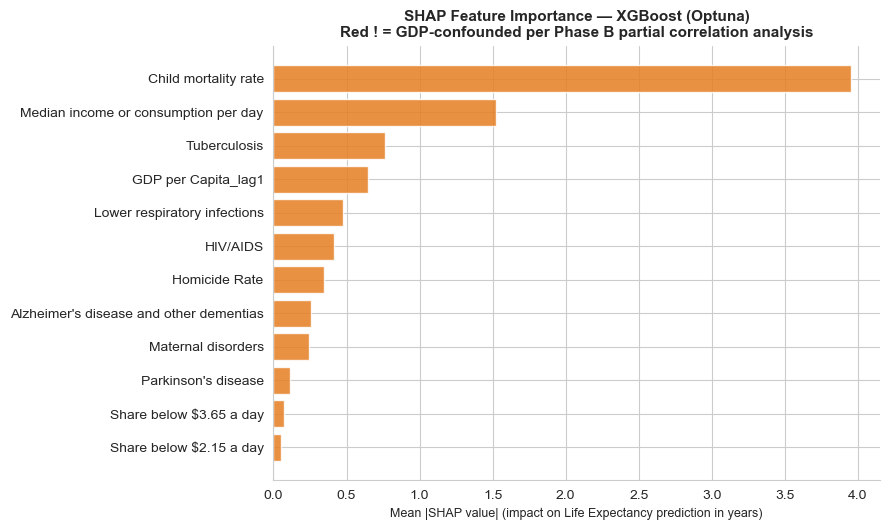

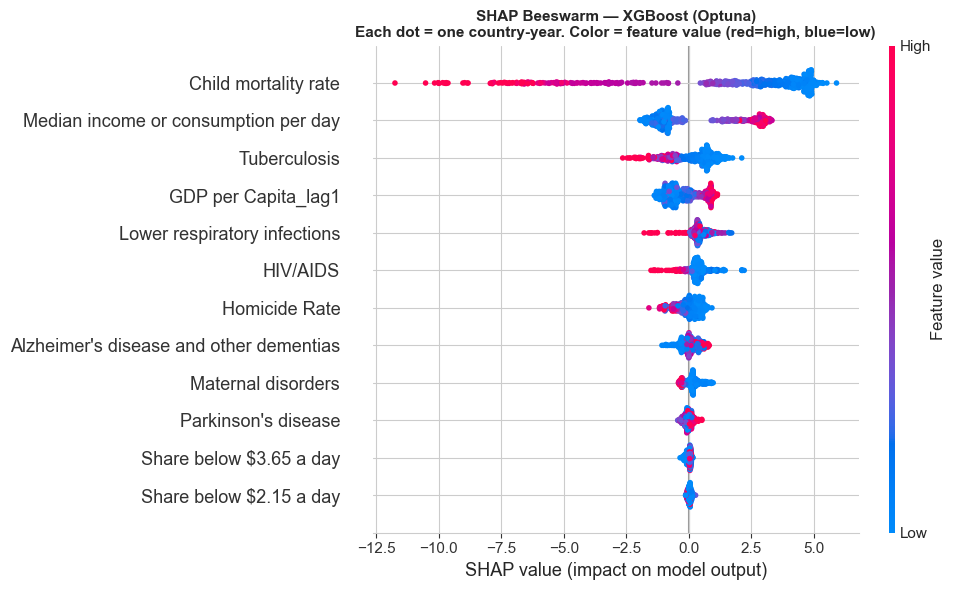

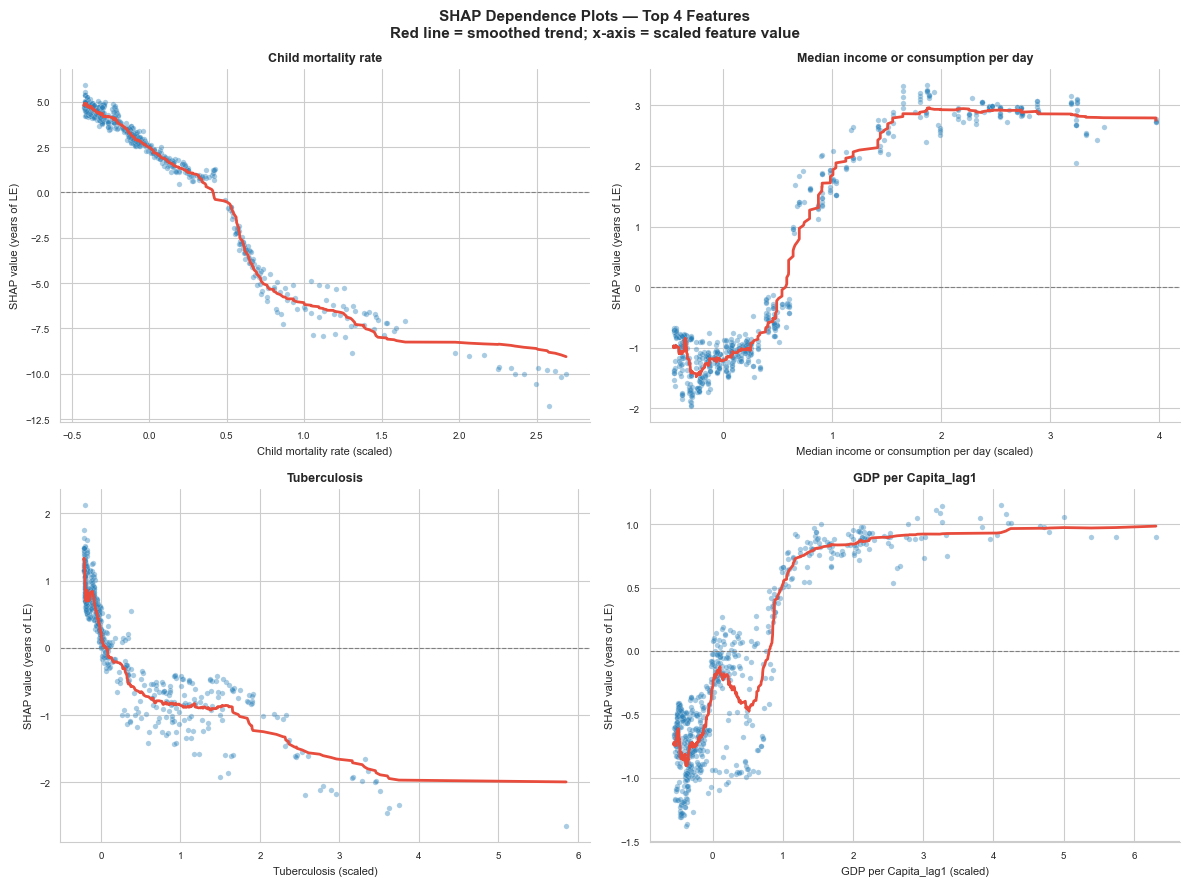

Phase B Correlation Rank vs Phase C SHAP Rank:
Rank Delta > 0 = correlation overestimated importance
Rank Delta < 0 = SHAP finds this more important than correlation suggested


,Feature,SHAP Rank,SHAP |mean|,Corr Rank,Rank Delta,GDP Confounded
0,Child mortality rate,1,3.953254,1.0,0.0,
1,Median income or consumption per day,2,1.520063,4.0,2.0,
2,Tuberculosis,3,0.765007,2.0,-1.0,
3,GDP per Capita_lag1,4,0.649780,NaN,NaN,
4,Lower respiratory infections,5,0.476410,10.0,5.0,
5,HIV/AIDS,6,0.417181,12.0,6.0,
6,Homicide Rate,7,0.348584,11.0,4.0,
7,Alzheimer's disease and other dementias,8,0.258759,5.0,-3.0,
8,Maternal disorders,9,0.245498,3.0,-6.0,
9,Parkinson's disease,10,0.115421,6.0,-4.0,


In [11]:
# ── 7a. Compute SHAP values ───────────────────────────────────────────────────

if SHAP_AVAILABLE:
    # Use TreeExplainer for tree-based models, LinearExplainer for linear
    is_tree_model = hasattr(best_model, 'feature_importances_')

    if is_tree_model:
        explainer   = shap.TreeExplainer(best_model)
        shap_values = explainer.shap_values(X_test_s)
    else:
        explainer   = shap.LinearExplainer(best_model, X_train_s)
        shap_values = explainer.shap_values(X_test_s)

    print(f'✅ SHAP values computed: shape={shap_values.shape}')

    # Build SHAP DataFrame
    df_shap = pd.DataFrame(shap_values, columns=feature_cols)
    shap_mean_abs = df_shap.abs().mean().sort_values(ascending=False)

    print('\nGlobal SHAP feature importance (mean |SHAP|):')
    for feat, val in shap_mean_abs.items():
        print(f'  {feat:<40}  {val:.3f}')
else:
    print('⚠️  SHAP not available — install with: pip install shap')
    # Fallback: use permutation importance
    perm = permutation_importance(best_model, X_test_s, y_test, n_repeats=20, random_state=SEED)
    shap_mean_abs = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)
    print('\nPermutation importance (fallback):')
    print(shap_mean_abs.round(4).to_string())

# ── 7b. SHAP summary bar plot ─────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, max(5, len(feature_cols) * 0.45)))

bars = ax.barh(shap_mean_abs.index[::-1], shap_mean_abs.values[::-1],
               color='#e67e22', alpha=0.85, edgecolor='white')

# Annotate bars with GDP-confounded flag
for bar, feat in zip(bars, shap_mean_abs.index[::-1]):
    flag = ' ⚠️ GDP' if feat in gdp_confounded else ''
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
            flag, va='center', fontsize=7, color='#e74c3c')

ax.set_xlabel('Mean |SHAP value| (impact on Life Expectancy prediction in years)', fontsize=9)
ax.set_title(f'SHAP Feature Importance — {best_model_name}\n'
             'Red ! = GDP-confounded per Phase B partial correlation analysis',
             fontweight='bold', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

plt.show()

# ── 7c. SHAP beeswarm plot ────────────────────────────────────────────────────

if SHAP_AVAILABLE:
    plt.figure(figsize=(10, max(5, len(feature_cols) * 0.5)))
    shap.summary_plot(
        shap_values, X_test_s,
        feature_names=feature_cols,
        show=False, plot_size=None
    )
    plt.title(f'SHAP Beeswarm — {best_model_name}\n'
              'Each dot = one country-year. Color = feature value (red=high, blue=low)',
              fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('SHAP not available — skipping beeswarm')

# ── 7d. SHAP dependence plots for top 4 features ─────────────────────────────

if SHAP_AVAILABLE:
    top4 = shap_mean_abs.head(4).index.tolist()
    fig, axes = plt.subplots(2, 2, figsize=(12, 9))
    axes = axes.flatten()

    for ax, feat in zip(axes, top4):
        feat_idx = feature_cols.index(feat)
        feat_vals = X_test_s[:, feat_idx]
        shap_vals = shap_values[:, feat_idx]

        ax.scatter(feat_vals, shap_vals, alpha=0.4, s=15,
                   color='#2980b9', edgecolor='white', linewidth=0.2)
        ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')

        # Loess-style smoothing with rolling mean
        order = np.argsort(feat_vals)
        x_s, y_s = feat_vals[order], shap_vals[order]
        window = max(5, len(x_s) // 15)
        y_smooth = pd.Series(y_s).rolling(window, center=True, min_periods=1).mean().values
        ax.plot(x_s, y_smooth, color='#e74c3c', linewidth=2)

        ax.set_xlabel(f'{feat} (scaled)', fontsize=8)
        ax.set_ylabel('SHAP value (years of LE)', fontsize=8)
        ax.set_title(feat, fontweight='bold', fontsize=9)
        ax.tick_params(labelsize=7)
        ax.spines[['top', 'right']].set_visible(False)

    plt.suptitle('SHAP Dependence Plots — Top 4 Features\n'
                 'Red line = smoothed trend; x-axis = scaled feature value',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

else:
    print('SHAP not available — skipping dependence plots')

# ── 7e. Correlation rank vs SHAP rank comparison ──────────────────────────────

# Phase B correlation ranking (from candidates — already sorted by score)
corr_rank = {feat: i + 1 for i, feat in enumerate(candidates_correlations.keys())}

# SHAP ranking
shap_rank = {feat: i + 1 for i, feat in enumerate(shap_mean_abs.index)}

rank_df = pd.DataFrame({
    'Feature'    : list(shap_rank.keys()),
    'SHAP Rank'  : list(shap_rank.values()),
    'SHAP |mean|': [shap_mean_abs[f] for f in shap_rank],
    'Corr Rank'  : [corr_rank.get(f, np.nan) for f in shap_rank],
})
rank_df['Rank Delta'] = rank_df['Corr Rank'] - rank_df['SHAP Rank']
rank_df['GDP Confounded'] = rank_df['Feature'].isin(gdp_confounded).map({True: '⚠️', False: ''})

print('Phase B Correlation Rank vs Phase C SHAP Rank:')
print('Rank Delta > 0 = correlation overestimated importance')
print('Rank Delta < 0 = SHAP finds this more important than correlation suggested')
display(rank_df.sort_values('SHAP Rank'))

---
# **8. Residual Analysis — Where the Model is Wrong and Why**

Countries with largest average residual (test period):


,Country,Continent,Mean_LE,Mean_Predicted,Mean_Residual,Mean_Abs_Residual,Direction
36,Fiji,Oceania,66.66,70.379997,-3.72,3.72,Overpredicted ↓
8,Bangladesh,Asia,72.82,69.379997,3.44,3.44,Underpredicted ↑
12,Bolivia,South America,65.63,69.070000,-3.44,3.44,Overpredicted ↓
85,Nigeria,Africa,53.62,56.950001,-3.33,3.33,Overpredicted ↓
16,Bulgaria,Europe,73.95,77.209999,-3.26,3.26,Overpredicted ↓
98,Sao Tome and Principe,Africa,68.60,71.559998,-2.96,2.96,Overpredicted ↓
59,Kazakhstan,Asia,72.58,75.510002,-2.93,2.93,Overpredicted ↓
0,Albania,Europe,78.50,75.760002,2.75,2.75,Underpredicted ↑
104,South Africa,Africa,64.96,67.629997,-2.67,2.67,Overpredicted ↓
32,El Salvador,North America,71.20,73.849998,-2.66,2.66,Overpredicted ↓


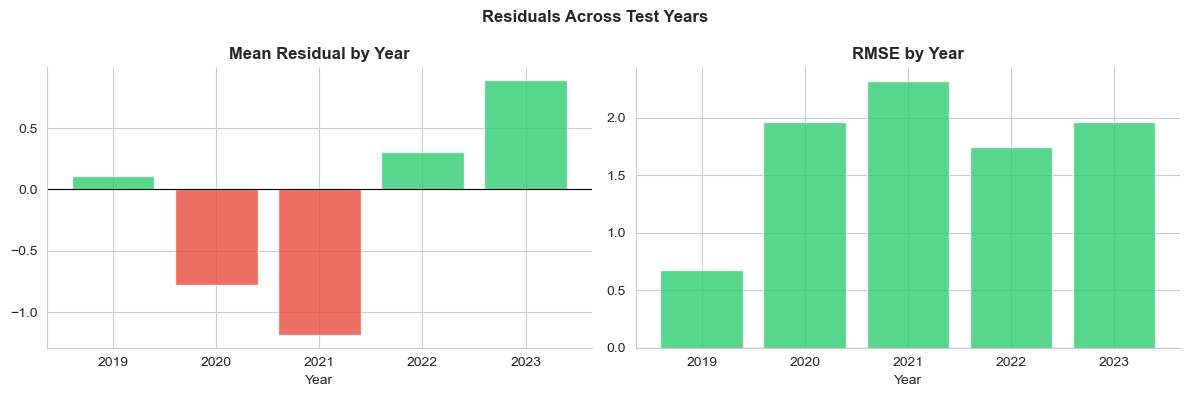

In [12]:
# ── 8a. Largest residuals — who is the model most wrong about ─────────────────

df_test_results['Abs_Residual'] = df_test_results['Residual'].abs()

# Aggregate to country level for the test period
df_resid_country = (
    df_test_results
    .groupby(['Country', 'Continent'])
    .agg(
        Mean_Residual   =('Residual',     'mean'),
        Mean_Abs_Residual=('Abs_Residual','mean'),
        Mean_LE         =(TARGET,         'mean'),
        Mean_Predicted  =('Predicted',    'mean'),
        N_Years         =('Year',         'count')
    )
    .reset_index()
    .sort_values('Mean_Abs_Residual', ascending=False)
)
df_resid_country['Direction'] = df_resid_country['Mean_Residual'].apply(
    lambda r: 'Underpredicted ↑' if r > 0 else 'Overpredicted ↓'
)

print('Countries with largest average residual (test period):')
display(df_resid_country.head(15)[[
    'Country', 'Continent', 'Mean_LE', 'Mean_Predicted',
    'Mean_Residual', 'Mean_Abs_Residual', 'Direction'
]].round(2))

# ── 8b. Residual map by country ───────────────────────────────────────────────

fig = px.choropleth(
    df_resid_country,
    locations='Country',
    locationmode='country names',
    color='Mean_Residual',
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    hover_name='Country',
    hover_data={'Mean_LE': ':.1f', 'Mean_Predicted': ':.1f',
                'Mean_Residual': ':.2f', 'Continent': True},
    title=f'Residual Map — {best_model_name}  (test period {min(TEST_YEARS)}–{max(TEST_YEARS)})<br>'
          '<sub>Blue = model overpredicts | Red = model underpredicts</sub>',
)
fig.update_layout(height=500, template='plotly_white',
                  coloraxis_colorbar=dict(title='Residual (years)'))
fig.show()

# ── 8c. Residuals over time — does error change with year ─────────────────────

df_resid_year = (
    df_test_results.groupby('Year')
    .agg(Mean_Residual=('Residual', 'mean'),
         RMSE=('Residual', lambda x: np.sqrt((x**2).mean())))
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes,
                           ['Mean_Residual', 'RMSE'],
                           ['Mean Residual by Year', 'RMSE by Year']):
    ax.bar(df_resid_year['Year'], df_resid_year[col],
           color=['#2ecc71' if v >= 0 else '#e74c3c' for v in df_resid_year[col]],
           alpha=0.8, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Year')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Residuals Across Test Years', fontweight='bold')
plt.tight_layout()
plt.show()


---
# **9. Panel Model Baseline — Fixed Effects**

A country Fixed Effects (FE) model controls for all time-invariant country characteristics (culture, geography, institutions) by demeaning within each country. It answers: *how much does a change in X within a country, over time, predict a change in LE?*

This is an important interpretability benchmark:
- If our ML model barely beats FE → the relationship is mostly cross-sectional, not causal
- If ML beats FE substantially → the model captures non-linear within-country dynamics

Fixed Effects Model (within-demeaning):
  Within R²   = -0.042  (explains within-country variation)
  Within RMSE = 1.13 years

Comparison:
  FE model within-R²         : -0.042
  XGBoost (Optuna) test R²  : 0.929
  ML advantage over FE       : +0.970

Fixed Effects Coefficients (within-country effect on LE):


,Feature,FE_Coef
0,Child mortality rate,-0.558
5,Parkinson's disease,0.162
8,GDP per Capita_lag1,0.152
3,Median income or consumption per day,0.124
4,Alzheimer's disease and other dementias,0.119
6,Share below $3.65 a day,-0.090
7,Share below $2.15 a day,0.060
1,Tuberculosis,-0.051
9,Lower respiratory infections,0.037
10,Homicide Rate,-0.034


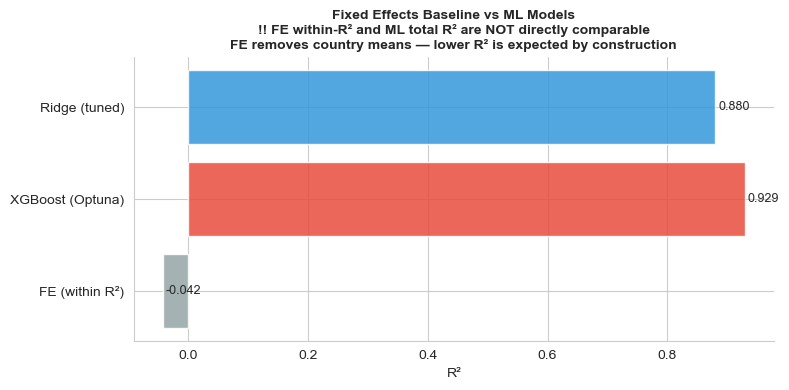


⚠️Note: FE within-R² and ML total R² measure different things.
   FE explains variance after removing country means (purer causal signal).
   ML explains total variance including between-country differences.


In [13]:
# ── 9a. Fixed Effects via within-demeaning ────────────────────────────────────

def apply_within_demean(df, feature_cols, target, group_col='Country'):
    """Demean features and target within each group (country). Returns demeaned arrays."""
    df_dm = df.copy()
    for col in feature_cols + [target]:
        df_dm[f'{col}_dm'] = df_dm[col] - df_dm.groupby(group_col)[col].transform('mean')
    feat_dm_cols = [f'{c}_dm' for c in feature_cols]
    tgt_dm_col   = f'{target}_dm'
    return df_dm[feat_dm_cols].values, df_dm[tgt_dm_col].values, feat_dm_cols


# Use all data (train+test) for FE to show in-sample fit
X_dm_train, y_dm_train, feat_dm_cols = apply_within_demean(df_train, feature_cols, TARGET)
X_dm_test,  y_dm_test,  _            = apply_within_demean(df_test,  feature_cols, TARGET)

# Scale demeaned features
scaler_dm    = RobustScaler()
X_dm_train_s = scaler_dm.fit_transform(X_dm_train)
X_dm_test_s  = scaler_dm.transform(X_dm_test)

# OLS on demeaned = Fixed Effects model
fe_model = LinearRegression(fit_intercept=False)  # no intercept after demeaning
fe_model.fit(X_dm_train_s, y_dm_train)

y_pred_fe_test = fe_model.predict(X_dm_test_s)

# Note: FE R² is computed on demeaned residuals, so it will be lower than ML R²
# (the FE model cannot predict the between-country component by construction)
fe_r2_within   = r2_score(y_dm_test, y_pred_fe_test)
fe_rmse_within = np.sqrt(mean_squared_error(y_dm_test, y_pred_fe_test))

print('Fixed Effects Model (within-demeaning):')
print(f'  Within R²   = {fe_r2_within:.3f}  (explains within-country variation)')
print(f'  Within RMSE = {fe_rmse_within:.2f} years')

print(f'\nComparison:')
print(f'  FE model within-R²         : {fe_r2_within:.3f}')
print(f'  {best_model_name} test R²  : {results_all[best_model_name]["R2"]:.3f}')
print(f'  ML advantage over FE       : {results_all[best_model_name]["R2"] - fe_r2_within:+.3f}')

# FE coefficients
fe_coef = pd.DataFrame({
    'Feature'   : feature_cols,
    'FE_Coef'   : fe_model.coef_
}).sort_values('FE_Coef', key=abs, ascending=False)

print('\nFixed Effects Coefficients (within-country effect on LE):')
display(fe_coef.round(3))

# ── 9b. FE vs ML comparison chart ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))

models_compare = [
    ('FE (within R²)', fe_r2_within),
    (best_model_name, results_all[best_model_name]['R2']),
    ('Ridge (tuned)', results_all.get('Ridge (tuned)', {}).get('R2', np.nan)),
]
models_compare = [(n, v) for n, v in models_compare if not np.isnan(v)]

names, scores = zip(*models_compare)
colors = ['#95a5a6'] + ['#e74c3c'] + ['#3498db'] * (len(models_compare) - 2)

ax.barh(names, scores, color=colors[:len(names)], alpha=0.85, edgecolor='white')
for i, (n, v) in enumerate(zip(names, scores)):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('R²')
ax.set_title('Fixed Effects Baseline vs ML Models\n'
             '!! FE within-R² and ML total R² are NOT directly comparable\n'
             'FE removes country means — lower R² is expected by construction',
             fontweight='bold', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

plt.show()

print('\n⚠️Note: FE within-R² and ML total R² measure different things.')
print('   FE explains variance after removing country means (purer causal signal).')
print('   ML explains total variance including between-country differences.')

---
# **10. Export — Model, SHAP Values, Feature Ranking for Phase D**

In [14]:
# ── 10a. Save best model + scaler ─────────────────────────────────────────────

joblib.dump(best_model, 'Phase_C_docs/best_model.joblib')
joblib.dump(scaler,     'Phase_C_docs/feature_scaler.joblib')

print(f'✅ Saved: best_model.joblib  ({best_model_name})')
print(f'✅ Saved: feature_scaler.joblib')

# Save model metadata
model_meta = {
    'model_name'    : best_model_name,
    'feature_cols'  : feature_cols,
    'lag_applied'   : {k: int(v) for k, v in lag_applied.items()},
    'train_years'   : [int(min(TRAIN_YEARS)), int(max(TRAIN_YEARS))],
    'test_years'    : [int(min(TEST_YEARS)), int(max(TEST_YEARS))],
    'test_r2'       : round(results_all[best_model_name]['R2'], 4),
    'test_rmse'     : round(results_all[best_model_name]['RMSE'], 4),
    'test_mae'      : round(results_all[best_model_name]['MAE'], 4),
    'cv_r2'         : round(results_all[best_model_name].get('CV_R2', 0), 4),
    'gdp_confounded': gdp_confounded,
}
with open('Phase_C_docs/model_metadata.json', 'w') as f:
    _json.dump(model_meta, f, indent=2)
print(f'✅ Saved: model_metadata.json')

# ── 10b. Export SHAP feature ranking → Phase D feature pool ───────────────────

# Build SHAP-ranked candidates dict (same format as candidates_correlations.json)
# Phase D clustering should use this instead of the correlation-based ranking

shap_ranked_features = shap_mean_abs.reset_index()
shap_ranked_features.columns = ['Feature', 'Mean_Abs_SHAP']
shap_ranked_features['SHAP_Rank']     = shap_ranked_features.index + 1
shap_ranked_features['Corr_Rank']     = shap_ranked_features['Feature'].map(
    lambda f: corr_rank.get(f, np.nan)
)
shap_ranked_features['Lag_Applied']   = shap_ranked_features['Feature'].map(
    lambda f: lag_applied.get(f, 0)
)
shap_ranked_features['GDP_Confounded'] = shap_ranked_features['Feature'].isin(gdp_confounded)
shap_ranked_features['Mean_Abs_SHAP']  = shap_ranked_features['Mean_Abs_SHAP'].round(4)

shap_ranked_features.to_csv('Phase_C_docs/shap_feature_ranking.csv', index=False)
# print('✅ Saved: shap_feature_ranking.csv')
display(shap_ranked_features)

# Export as JSON for Phase D (same format as candidates_correlations.json)
candidates_phase_d = {
    row['Feature']: candidates_correlations.get(row['Feature'], row['Feature'])
    for _, row in shap_ranked_features.iterrows()
    if row['Mean_Abs_SHAP'] > 0  # drop features SHAP zeroed out
}
with open('Phase_C_docs/candidates_shap.json', 'w') as f:
    _json.dump(candidates_phase_d, f, indent=2)
print('✅ Saved: candidates_shap.json  (use this in phase_b_clustering.ipynb → re-run clustering)')

# ── 10c. Export test set predictions with residuals ───────────────────────────

export_cols = ['Country', 'Continent', 'Year', TARGET, 'Predicted', 'Residual', 'Abs_Residual']
df_test_results[export_cols].to_csv('Phase_C_docs/model_predictions_test.csv', index=False)
print('✅ Saved: model_predictions_test.csv')

df_resid_country.to_csv('Phase_C_docs/model_residuals_by_country.csv', index=False)
print('✅ Saved: model_residuals_by_country.csv')

df_comparison.to_csv('Phase_C_docs/model_comparison_all.csv', index=False)
print('✅ Saved: model_comparison_all.csv')

# ── 10d. Export SHAP values per observation ────────────────────────────────────

if SHAP_AVAILABLE:
    df_shap_export = pd.DataFrame(shap_values, columns=[f'SHAP_{c}' for c in feature_cols])
    df_shap_export['Country']   = df_test['Country'].values
    df_shap_export['Year']      = df_test['Year'].values
    df_shap_export['Continent'] = df_test['Continent'].values
    df_shap_export[TARGET]      = y_test
    df_shap_export['Predicted'] = y_pred_test
    df_shap_export.to_csv('Phase_C_docs/shap_values_test.csv', index=False)
    print('✅ Saved: shap_values_test.csv')

✅ Saved: best_model.joblib  (XGBoost (Optuna))
✅ Saved: feature_scaler.joblib
✅ Saved: model_metadata.json


,Feature,Mean_Abs_SHAP,SHAP_Rank,Corr_Rank,Lag_Applied,GDP_Confounded
0,Child mortality rate,3.9533,1,1.0,0,False
1,Median income or consumption per day,1.5201,2,4.0,0,False
2,Tuberculosis,0.7650,3,2.0,0,False
3,GDP per Capita_lag1,0.6498,4,NaN,1,False
4,Lower respiratory infections,0.4764,5,10.0,0,False
5,HIV/AIDS,0.4172,6,12.0,0,False
6,Homicide Rate,0.3486,7,11.0,0,False
7,Alzheimer's disease and other dementias,0.2588,8,5.0,0,False
8,Maternal disorders,0.2455,9,3.0,0,False
9,Parkinson's disease,0.1154,10,6.0,0,False


✅ Saved: candidates_shap.json  (use this in phase_b_clustering.ipynb → re-run clustering)
✅ Saved: model_predictions_test.csv
✅ Saved: model_residuals_by_country.csv
✅ Saved: model_comparison_all.csv
✅ Saved: shap_values_test.csv


---
## **~Phase C Outputs Summary~**

| File | Description |
|------|-------------|
| `best_model.joblib` | Fitted best model (load with `joblib.load`) |
| `feature_scaler.joblib` | RobustScaler fitted on training data |
| `model_metadata.json` | Model name, features, lags, test metrics |
| `candidates_shap.json` | SHAP-ranked feature pool → **use in Phase D clustering** |
| `shap_feature_ranking.csv` | Full SHAP ranking with correlation rank comparison |
| `shap_values_test.csv` | Per-observation SHAP values on test set |
| `model_predictions_test.csv` | Test set predictions + residuals |
| `model_residuals_by_country.csv` | Country-level residual summary |
| `model_comparison_all.csv` | All models compared — R², RMSE, MAE |
| `model_comparison.png` | Visual comparison chart |
| `predicted_vs_actual.png` | Scatter + residual histogram |
| `shap_feature_importance.png` | Global SHAP bar chart |
| `shap_beeswarm.png` | SHAP beeswarm (direction + magnitude) |
| `shap_dependence_top4.png` | Dependence plots for top 4 features |
| `residuals_by_year.png` | Residual drift over test years |
| `fe_vs_ml_comparison.png` | Fixed Effects vs ML benchmark |

### Key decisions made
1. **Temporal split** — 2000–2018 train, 2019–2023 test — prevents future leakage
2. **RobustScaler** — median/IQR normalisation, robust to outlier countries
3. **Lag-aware features** — applied Phase B lag recommendations within-country
4. **Fixed Effects baseline** — establishes whether ML adds value beyond within-country trends
5. **SHAP over permutation importance** — captures interaction effects; consistent with model

### Next: Phase D — `phase_b_clustering.ipynb` (re-run)
Load `candidates_shap.json` instead of `candidates_correlations.json` to ground peer groups in the model-validated feature ranking. Then proceed to cause-of-death analysis and policy recommendations.

```python
# In phase_b_clustering.ipynb, change:
CANDIDATES_PATH = 'candidates_shap.json'   # was candidates_correlations.json
```